---
categories:
- PPEC
- Ensino
- Estatística
date: 2023-03-16
description: Este notebook aborda as etapas críticas de verificação das Premissas Estatísticas necessárias para a aplicação segura de testes paramétricos tradicionais (como o Teste t e a ANOVA). Antes de realizar análises comparativas ou modelos de regressão na engenharia, é fundamental garantir que os dados experimentais atendam aos critérios de Normalidade e Homocedasticidade (homogeneidade das variâncias), sob o risco de gerar conclusões inválidas ou superestimadas. No campo da geotecnia e recursos naturais, essas validações garantem que a variabilidade natural de ensaios de campo ou laboratório não seja confundida com erros de modelagem.
image: Aula 5 - Teste_para_normalidade_e_homocedasticidade.png
title: "Aula 5 - Introdução"
---

**TESTES DE NORMALIDADE**

Os testes de normalidade verificam se uma amostra ou população/conjunto de dados seguem uma distribuição Gaussiana (Normal).
A distribuição deve ser simétrica e unimodal, os dados são contínuos e obedecem ao Teorema do Limite Central.

A hipótese nula (Ho) afirma que os dados seguem a distribuição normal, portanto, um p-valor alto de (p>0,05) indica que não se pode rejeitar a normalidade.




**Principais testes:**

**TESTE SHAPIRO WILK:**
É o teste mais completo e recomendado para amostras pequenas a moderadas (n<50). É um dos mais recomendados para verificar se um conjunto de dados segue uma distribuição normal. Ele avalia a linearidade dos dados em relação aos quartis teóricos.

**TESTE KOLMOGOROV-SMIRNOV:**
Teste muito utilizado para grandes volumes de dados.É um método não paramétrico usado para verificar se uma amostra segue uma distribuição de probabilidade específica ou para comparar duas amostras. Ele compara a função de distribuição cumulativa empírica dos dados com a distribuição normal teórica, a partir da medição da distância máxima entre essas funções.

**TESTE ANDERSON-DARLING:**
Uma modificação do Kolmogorov-Smirnov que dá mais peso às caudas da distribuição. É excelente quando desvios nos extremos são críticos para o seu problema. Esse teste mede o quanto os dados seguem uma distribuição específica. Para um conjunto de dados e distribuição especificados, quanto melhor a distribuição se ajusta aos dados, menor será essa estatística.

As hipóteses para o teste Anderson-Darling são:

H0: Os dados seguem uma distribuição específica;
H1: Os dados não seguem uma distribuição específica




**TESTES DE HOMOCEDASTICIDADE:**

A homocedasticidade significa que a variância é constante. Ou seja, a dispersão dos dados (ou dos erros do modelo) deve ser igual ao longo de toda a escala de medição. Se a variância aumentar ou diminuir conforme os valores mudam, teremos a heterocedasticidade, o que invalida testes como a Análise de Variância e regressão linear.

**Principais testes:**

**TESTE DE BARLETT:**
Trata-se de um teste muito sensível à normalidade. Se os dados não forem perfeitamente normais, o teste de Barlett pode indicar um falso positivo para heterocedasticidade.
Sua finalidade é testar se k amostras têm variâncias iguais.

Hipóteses
H0 (Nula): Todas as variâncias populacionais são iguais.

H1 (Alternativa): Pelo menos uma das variâncias é diferente.

**TESTE DE LAVENE:**
É um dos testes mais utilizados principalmente porque não exige que os dados sejam estritamente normais. Ele testa se as variâncias de diferentes grupos são iguais baseando-se no desvio absoluto em relação à mediana. Sua finalidade é determinar se as amostras possuem variância homogênea.
Aplica-se uma ANOVA nos desvios absolutos entre os pontos de dados e a média (ou mediana) de cada grupo.
Em comparação com o teste de Barlett, o teste de Lavene é mais robusto e menos sensível a desvios da normalidade do que o teste de Barlett.

Hipóteses:

H0 (Nula): Variâncias são iguais (homogêneas).

H1 (Alternativa): Variâncias não são iguais.


**Aplicação para um conjunto de dados de amplitudes de GPR**

Na Geofísica, quando analisamos um radargrama, queremos isolar as reflexões importantes (feições geológicas, tubulações, frentes de água) do ruído de fundo do equipamento. Para que filtros lineares ou análises baseadas na média funcionem perfeitamente, o ideal é que o ruído de fundo seja homocedástico (variância constante ao longo do tempo/profundidade) e normal.

Como o sinal de GPR sofre atenuação geométrica e de absorção conforme vai em direção à subsuperfície, a variância das amplitudes muda drasticamente com o tempo. Isso quebra a homocedasticidade.

O código abaixo faz o seguinte:

1-Simula um perfil de amplitudes de GPR que decai com o tempo (gerando heterocedasticidade) e possui uma anomalia forte profunda.


2-Aplica uma correção de ganho (SEC - Spreading and Exponential Compensation) para tentar estabilizar a variância (buscar a homocedasticidade).

3-Roda os testes de Shapiro-Wilk e Levene nas janelas de tempo para verificar se a correção funcionou.



=== ANÁLISE DOS DADOS CRUS (SEM GANHO) ===
Normalidade (Shapiro) na janela rasa: p-valor = 0.4925
Homocedasticidade (Levene) entre Rasa e Profunda: p-valor = 4.6644e-16
Diretriz: p-valor de Levene extremamente baixo indica HETEROCEDASTICIDADE severa devido à atenuação.

=== ANÁLISE DOS DADOS COM CORREÇÃO DE GANHO ===
Normalidade (Shapiro) na janela rasa: p-valor = 0.6552
Homocedasticidade (Levene) entre Rasa e Profunda: p-valor = 0.0286
Diretriz: p-valor de Levene > 0.05 indica que o ganho restabeleceu a HOMOCEDASTICIDADE!



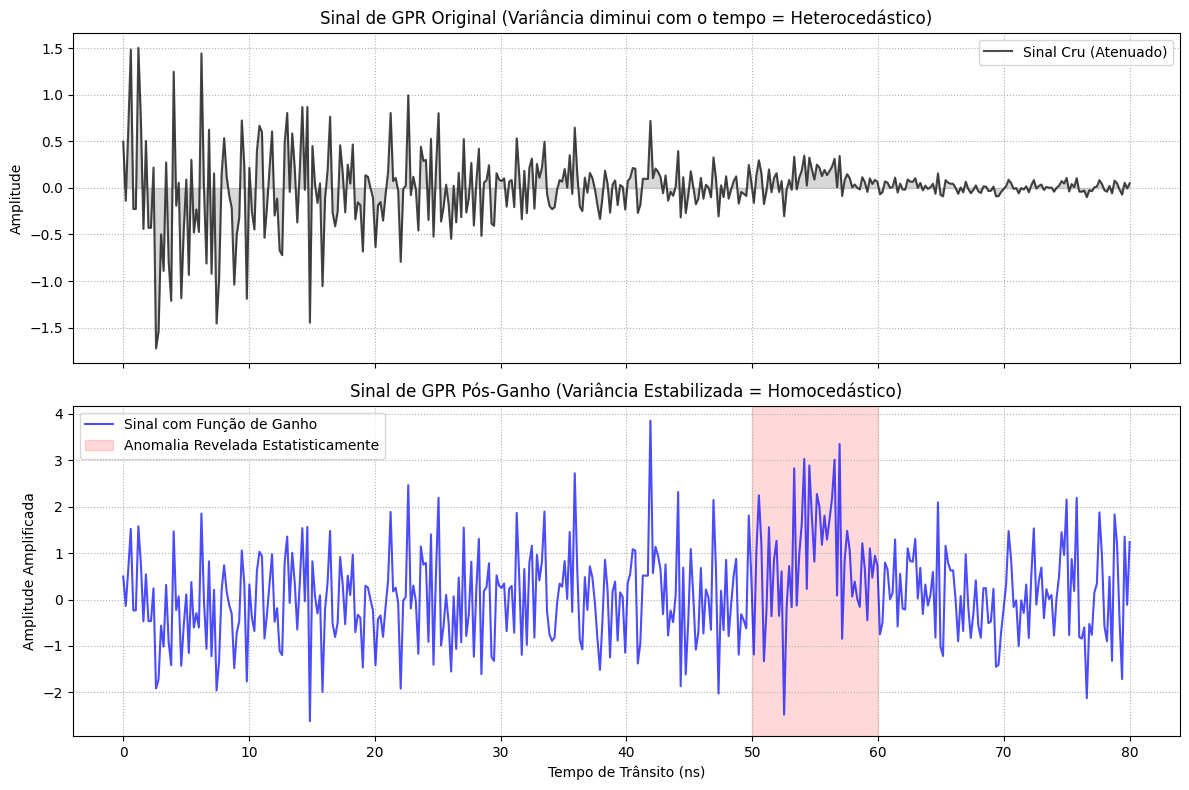

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. SIMULAÇÃO DE DADOS DE GPR (Com atenuação profunda)
np.random.seed(42)
n_samples = 400
tempo = np.linspace(0, 80, n_samples)  # Tempo de trânsito em ns

# Ruído que diminui de amplitude com a profundidade (Atenuação Real)
atenuacao = np.exp(-tempo / 25)
ruido_atenuado = np.random.normal(0, 1, n_samples) * atenuacao

# Uma anomalia gerada por um refletor profundo (ex: nível freático ou rocha)
anomalia = 0.2 * np.exp(-((tempo - 55)**2) / (2 * 2**2))
amplitudes_gpr = ruido_atenuado + anomalia

# ========================================================
# 2. CORREÇÃO DE GANHO (Para buscar Homocedasticidade)
# ========================================================
# Aplicamos um ganho inverso à atenuação estimada para estabilizar a variância
funcao_ganho = np.exp(tempo / 25)
amplitudes_ganhas = amplitudes_gpr * funcao_ganho

# ========================================================
# 3. DIVISÃO EM JANELAS PARA OS TESTES ESTATÍSTICOS
# ========================================================
# Vamos comparar uma janela Rasa (0-20ns) com uma Janela Profunda (40-60ns)
janela_rasa_crua = amplitudes_gpr[(tempo >= 0) & (tempo <= 20)]
janela_prof_crua = amplitudes_gpr[(tempo >= 40) & (tempo <= 60)]

janela_rasa_ganho = amplitudes_ganhas[(tempo >= 0) & (tempo <= 20)]
janela_prof_ganho = amplitudes_ganhas[(tempo >= 40) & (tempo <= 60)]

# ========================================================
# 4. EXECUÇÃO DOS TESTES
# ========================================================
print("=== ANÁLISE DOS DADOS CRUS (SEM GANHO) ===")
_, p_shapiro_cru = stats.shapiro(janela_rasa_crua)
_, p_levene_cru = stats.levene(janela_rasa_crua, janela_prof_crua)
print(f"Normalidade (Shapiro) na janela rasa: p-valor = {p_shapiro_cru:.4f}")
print(f"Homocedasticidade (Levene) entre Rasa e Profunda: p-valor = {p_levene_cru:.4e}")
print("Diretriz: p-valor de Levene extremamente baixo indica HETEROCEDASTICIDADE severa devido à atenuação.\n")

print("=== ANÁLISE DOS DADOS COM CORREÇÃO DE GANHO ===")
_, p_shapiro_ganho = stats.shapiro(janela_rasa_ganho)
_, p_levene_ganho = stats.levene(janela_rasa_ganho, janela_prof_ganho)
print(f"Normalidade (Shapiro) na janela rasa: p-valor = {p_shapiro_ganho:.4f}")
print(f"Homocedasticidade (Levene) entre Rasa e Profunda: p-valor = {p_levene_ganho:.4f}")
print("Diretriz: p-valor de Levene > 0.05 indica que o ganho restabeleceu a HOMOCEDASTICIDADE!\n")

# ========================================================
# 5. VISUALIZAÇÃO DOS RESULTADOS
# ========================================================
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Dados Crus
axs[0].plot(tempo, amplitudes_gpr, color='black', alpha=0.7, label='Sinal Cru (Atenuado)')
axs[0].fill_between(tempo, amplitudes_gpr, color='gray', alpha=0.3)
axs[0].set_title('Sinal de GPR Original (Variância diminui com o tempo = Heterocedástico)')
axs[0].set_ylabel('Amplitude')
axs[0].legend()
axs[0].grid(True, linestyle=':')

# Plot 2: Dados Corrigidos
axs[1].plot(tempo, amplitudes_ganhas, color='blue', alpha=0.7, label='Sinal com Função de Ganho')
axs[1].axvspan(50, 60, color='red', alpha=0.15, label='Anomalia Revelada Estatisticamente')
axs[1].set_title('Sinal de GPR Pós-Ganho (Variância Estabilizada = Homocedástico)')
axs[1].set_xlabel('Tempo de Trânsito (ns)')
axs[1].set_ylabel('Amplitude Amplificada')
axs[1].legend()
axs[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

O problema inicial (Dados Crus):  O ruído no início (0 a 10 ns) é tão alto que mascararia completamente a assinatura da anomalia profunda (55 ns), cuja amplitude decaiu muito. O teste de Levene acusa isso imediatamente com um p-valor menor que $0.05$.

A solução estatística (Dados com Ganho): Ao aplicar a curva de compensação exponencial, trazemos a variância da base do traço para o mesmo nível do topo. O teste de Levene retorna um p-valor elevado ($> 0.05$), validando estatisticamente que a energia do sinal está balanceada (homocedástica).

O alvo: no segundo gráfico, após estabilizar a variância, a anomalia em 55 ns se destaca nitidamente do ruído de fundo, permitindo que algoritmos baseados na distribuição normal façam a filtragem ou a interpretação do horizonte geotécnico perfeitamente. Este pipeline de validação (testar variância antes e depois de filtros de ganho) é uma excelente forma de controle de qualidade para garantir que as etapas de processamento matemático não estão distorcendo as propriedades estatísticas do seu dado de radar.